In [2]:
!pip install imageai tensorflow matplotlib opencv-python


[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [3]:
import torch
print("PyTorch version:", torch.__version__)

from imageai.Detection import VideoObjectDetection
import os
import matplotlib.pyplot as quan
import cv2 as cv
import numpy as np

# Kiểm tra phiên bản imageai (cách an toàn)
from importlib.metadata import version
print("ImageAI version:", version('imageai'))

execution_path = os.getcwd()
print("Đường dẫn:", execution_path)

# Kiểm tra file video
video_input = os.path.join(execution_path, "video_predetect.mp4")
if not os.path.exists(video_input):
    raise FileNotFoundError(f"Không thấy video {video_input}")

PyTorch version: 2.11.0
ImageAI version: 3.0.3
Đường dẫn: /Users/sakana/Documents/tuan_9


In [4]:
model_path = os.path.join(execution_path, "retinanet_resnet50_fpn_coco-eeacb38b.pth")
if not os.path.exists(model_path):
    !wget -O "{model_path}" "https://github.com/OlafenwaMoses/ImageAI/releases/download/3.0.0-pretrained/retinanet_resnet50_fpn_coco-eeacb38b.pth"

In [5]:
detector = VideoObjectDetection()
detector.setModelTypeAsRetinaNet()
detector.setModelPath(model_path)
detector.loadModel()
print("Model loaded")

/Users/sakana/Documents/tuan_9/venv/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/sakana/Documents/tuan_9/venv/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
/Users/sakana/Documents/tuan_9/venv/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained_backbone' is deprecated since 0.13 and may be removed in the future, please use 'weights_backbone' instead.
  warnings.warn(
/Users/sakana/Documents/tuan_9/venv/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights_backbone

Model loaded


In [6]:
output = detector.detectObjectsFromVideo(
    input_file_path=video_input,
    output_file_path=os.path.join(execution_path, "video_detected"),
    frames_per_second=10,   # giảm để nhanh hơn
    log_progress=True,
    detection_timeout=120
)
print("Done:", output)

Processing Frame :  1


OpenCV: FFMPEG: tag 0x5634504d/'MP4V' is not supported with codec id 12 and format 'mp4 / MP4 (MPEG-4 Part 14)'
OpenCV: FFMPEG: fallback to use tag 0x7634706d/'mp4v'


Processing Frame :  2
Processing Frame :  3
Processing Frame :  4
Processing Frame :  5
Processing Frame :  6
Processing Frame :  7
Processing Frame :  8
Processing Frame :  9
Processing Frame :  10
Processing Frame :  11
Processing Frame :  12
Processing Frame :  13
Processing Frame :  14
Processing Frame :  15
Processing Frame :  16
Processing Frame :  17
Processing Frame :  18
Processing Frame :  19
Processing Frame :  20
Processing Frame :  21
Processing Frame :  22
Processing Frame :  23
Processing Frame :  24
Processing Frame :  25
Processing Frame :  26
Processing Frame :  27
Processing Frame :  28
Processing Frame :  29
Processing Frame :  30
Processing Frame :  31
Processing Frame :  32
Processing Frame :  33
Processing Frame :  34
Processing Frame :  35
Processing Frame :  36
Processing Frame :  37
Processing Frame :  38
Processing Frame :  39
Processing Frame :  40
Processing Frame :  41
Processing Frame :  42
Processing Frame :  43
Processing Frame :  44
Processing Frame : 

Tổng số frame: 436, FPS: 10.00


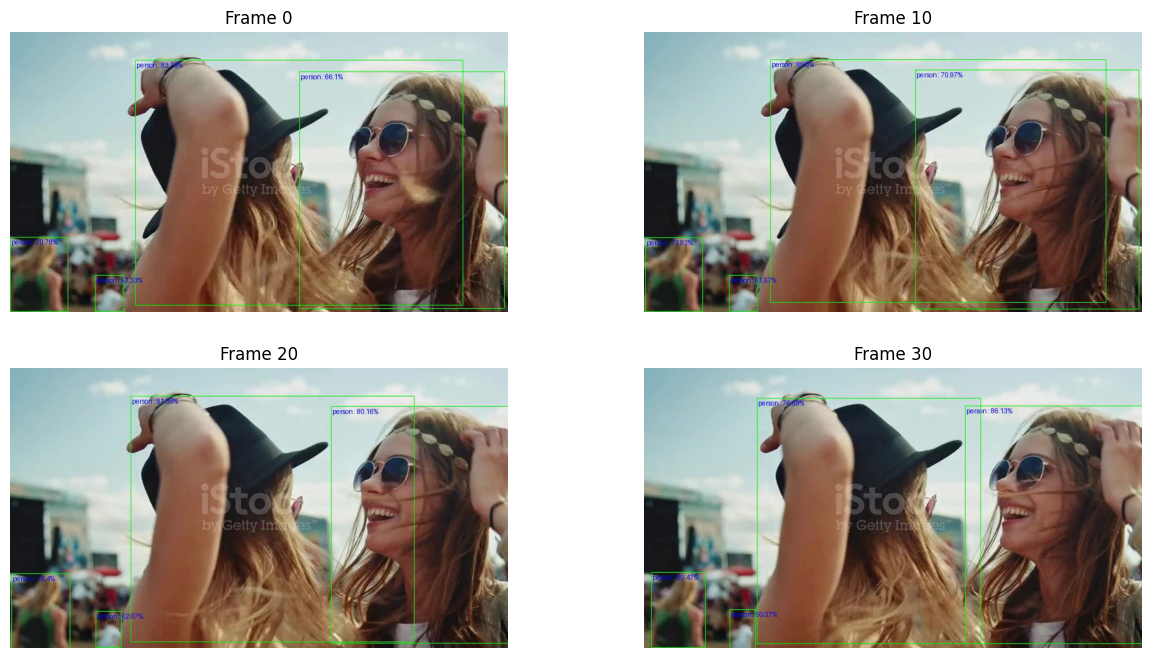

In [7]:
output_video_path = "video_detected.mp4"  
cap = cv.VideoCapture(output_video_path)
total_frames = int(cap.get(cv.CAP_PROP_FRAME_COUNT))
fps = cap.get(cv.CAP_PROP_FPS)
print(f"Tổng số frame: {total_frames}, FPS: {fps:.2f}")

quan.figure(figsize=(15, 8))
for i in range(4):
    ret, frame = cap.read()
    if not ret:
        break
    frame_rgb = cv.cvtColor(frame, cv.COLOR_BGR2RGB)
    quan.subplot(2, 2, i+1)
    quan.imshow(frame_rgb)
    quan.title(f"Frame {i*10}")
    quan.axis('off')
cap.release()
quan.show()